# 02 — Natural-language interface to factory data

**Frame for the room:** *Imagine this is one of your Kafka topics.* One
factory (`skjern_1`), three lines, six machines, five signals, two days of
10-second samples — long format, exactly the shape your IIoT pipeline already
produces.

The demo asks a natural-language question, gets back a **chart** and a
**plain-English annotation** of what changed. The pattern is intentional:

```
  question  ──LLM──▶  plan (JSON)  ──pandas──▶  window + stats  ──LLM──▶  annotation
```

The LLM is **only** the communication layer: it picks a signal, a machine
scope, and a time window from a known schema, and later phrases the computed
stats in English. Pandas does the actual work. This is what makes the
pattern safe on a factory floor — the dangerous part (execution) is
deterministic and reviewable; the soft part (English in, English out) is
where the LLM helps.

Why not anomaly detection alone? Classical statistics and small models
already solve threshold and drift detection. The thing classical ML *can't*
do is let a maintenance technician ask a question in Danish on a tablet at
07:30 and get back the right chart. That's the unique-value-add of an LLM
layer on top of your existing platform.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path('..').resolve() / 'src'))
from nl_query import (
    SCHEMA_CARD, OllamaClient, MockClient, default_mock_client, pick_client,
    make_plan, execute_plan, relevant_events, annotate, ask,
)

DATA_DIR = Path('..') / 'data'
measurements = pd.read_parquet(DATA_DIR / 'synthetic_factory.parquet')
events = pd.read_parquet(DATA_DIR / 'synthetic_events.parquet')

print(f'measurements: {len(measurements):,} rows  '
      f'({measurements.timestamp.min()} -> {measurements.timestamp.max()})')
print(f'events:       {len(events)} rows')

measurements: 518,400 rows  (2026-05-04 00:00:00+00:00 -> 2026-05-05 23:59:50+00:00)
events:       9 rows


## Pick a client

`pick_client()` tries Ollama on `localhost:11434`. If it's reachable, the
demo uses a small local model (default `qwen2.5vl:3b`, ~3.8 B params). If
not, it falls back to a deterministic mock so the demo always runs — even
on conference wifi.

Force one or the other if you want:

```python
client = OllamaClient(model='qwen2.5:3b')   # or 'llama3.2:3b'
client = default_mock_client()              # always-works fallback
```

In [2]:
client = pick_client()
print(f'Using client: {client.name}'
      + (f'  (model={client.model})' if hasattr(client, 'model') else ''))

# Warm up the model so the first live question isn't a 30-second wait.
if client.name == 'ollama':
    _ = client.complete('Reply with the word OK.', 'ping')
    print('warm-up done')

Using client: ollama  (model=qwen2.5vl:3b)


warm-up done


### What the LLM sees about your topic

One short schema card. No live SQL, no free-form query language — the model
picks from a known set of signals, machines, lines and time windows. This is
the **governance surface**: the schema card is what your platform team
controls.

In [3]:
print(SCHEMA_CARD)

You translate factory-floor questions into a JSON query plan.

The data is one Kafka topic, long format, one row per measurement:
  columns: timestamp (UTC), line_id, machine_id, signal, value, value_str

Signals (use these names exactly):
  - throughput_pcs_per_min   pieces per minute, float
  - motor_current_a          motor current in amps, float
  - temperature_c            motor temperature in C, float
  - vibration_rms_mm_s       vibration RMS in mm/s, float
  - packml_state             Execute / Idle / Stopped / Aborted (in value_str)

Lines and machines:
  line_1: folder_01, sash_assembler
  line_2: folder_02, glass_cutter
  line_3: edge_bonder, quality_station

Data window: 2026-05-04T00:00:00Z .. 2026-05-06T00:00:00Z (two days).
For date arithmetic treat "today" as 2026-05-06.
  "yesterday"       -> 2026-05-05T00:00:00Z .. 2026-05-06T00:00:00Z
  "Monday morning"  -> 2026-05-04T06:00:00Z .. 2026-05-04T12:00:00Z
  "last week"       -> the two available days

Return ONLY a JSON 

## Q1 — warm-up: a routine lookup

> *What was the throughput on line 2 yesterday?*

Boring question on purpose. Proves the pipeline works end-to-end before we
ask anything interesting. You can already do this with a Grafana dashboard
— the point is that you didn't have to *build* the dashboard first.

Q: What was the throughput on line 2 yesterday?
  client: ollama   intent: lookup   signal: throughput_pcs_per_min


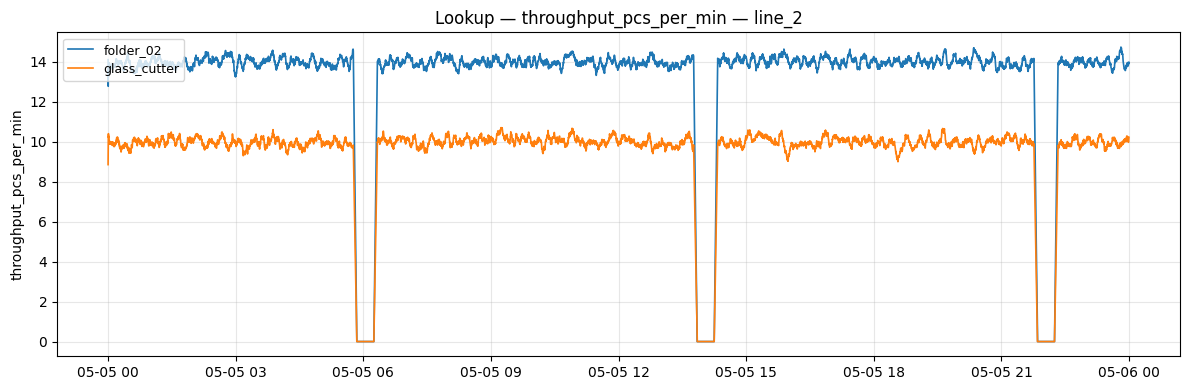

  machine_id   mean
   folder_02 13.151
glass_cutter  9.386

Events in window:
                timestamp machine_id severity    code                                                                                message
2026-05-05 08:15:00+00:00  folder_02  warning VIB_W02                               Vibration RMS sustained above warning threshold for 12h.
2026-05-05 09:30:00+00:00  folder_02    error VIB_E01                                  Vibration spike: 3.5x baseline. Inspect main bearing.
2026-05-05 09:45:00+00:00  folder_02     info OP_NOTE Maskinen lyder anderledes. Vil have vedligehold til at kigge på det inden næste skift.

Annotation:
Yesterday, the throughput on line 2 was 13.151 pcs per minute on average. The glass cutter had a throughput of 9.386 pcs per minute. There were two alarms reported: a warning for vibration RMS sustained above the warning threshold for 12 hours and an error for a vibration spike that was 3.5 times the baseline. An operator note was also record

In [4]:
_ = ask(
    'What was the throughput on line 2 yesterday?',
    measurements, events, client,
)

## Q2 — the headline: drift detection on a fleet

> *Show me machines on line 2 that drifted last week.*

This is where the LLM earns its place. *Drift* is a fuzzy word — the
engineer means "something is trending away from where it used to be".
Translating that into a baseline window, a comparison window, the right
signal, and a per-machine percentage delta — that's the LLM's job.
Computing the percentages is pandas's job.

Below the pipeline is unrolled so you can see each stage.

In [5]:
import json

question = 'Show me machines on line 2 that drifted last week.'

# Stage 1: question -> structured plan
plan = make_plan(question, client)
print('Plan:')
print(json.dumps(plan, indent=2))

Plan:
{
  "intent": "drift",
  "signal": "vibration_rms_mm_s",
  "line_id": "line_2",
  "machine_id": null,
  "time_window": {
    "start": "2026-05-05T00:00:00Z",
    "end": "2026-05-06T00:00:00Z"
  },
  "baseline": {
    "start": "2026-05-04T00:00:00Z",
    "end": "2026-05-04T18:00:00Z"
  },
  "aggregation": "mean"
}


In [6]:
# Stage 2: plan -> filtered window + stats (deterministic pandas, no LLM)
window, stats = execute_plan(plan, measurements)

print(f'Comparing window {stats["window_start"]} → {stats["window_end"]}')
print(f'   against baseline {stats["baseline_start"]} → {stats["baseline_end"]}\n')
print('Per-machine drift:')
print(pd.DataFrame(stats['per_machine']).to_string(index=False))
print()
print('Drifted > 20%:', stats['drifted_more_than_20pct'])

Comparing window 2026-05-05T00:00:00+00:00 → 2026-05-06T00:00:00+00:00
   against baseline 2026-05-04T00:00:00+00:00 → 2026-05-04T18:00:00+00:00

Per-machine drift:
  machine_id  baseline_mean  current_mean  delta_pct
   folder_02          2.381         5.052      112.2
glass_cutter          2.381         2.369       -0.5

Drifted > 20%: ['folder_02']


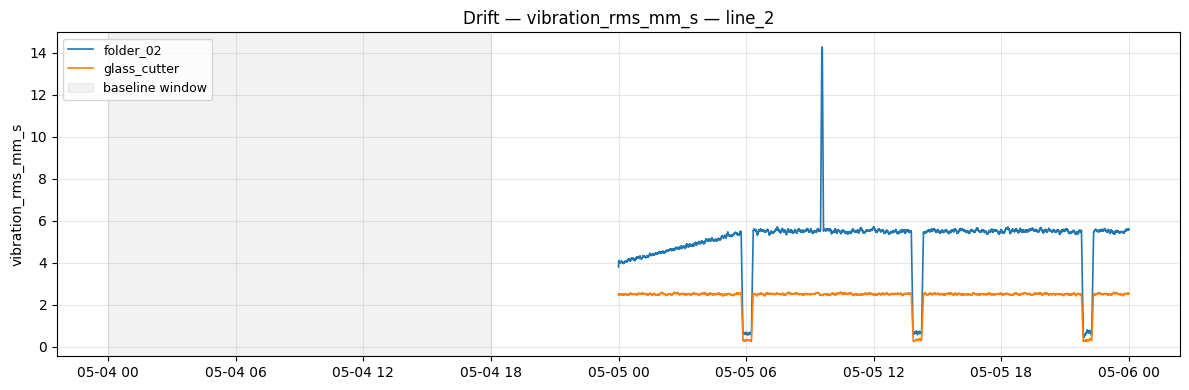

In [7]:
from nl_query import plot_result

fig, ax = plt.subplots(figsize=(12, 4))
plot_result(plan, window, stats, ax=ax)
plt.tight_layout()
plt.show()

In [8]:
# Stage 3: stats + events -> plain-English annotation (LLM, but only phrasing)
rel = relevant_events(plan, events)
annotation = annotate(question, stats, rel, client)
print(annotation)

The machine "folder_02" drifted significantly last week, with a delta percentage of 112.2%. This was the only machine that drifted more than 20%. The baseline drift started on May 4th and ended on May 4th at 6 PM. The machine "folder_02" also experienced two alarms: a warning at 8:15 AM and an error at 9:30 AM. An operator note was also recorded at 9:45 AM, stating that the machine sounded different and needed inspection.


## Q3 — anomaly + event correlation

> *What happened on the glass cutter Monday morning?*

The hardest of the three. The signal that matters depends on what *kind* of
thing went wrong, and the explanation needs to pull in alarms and operator
notes (some of which are in Danish) from a separate events topic.

Classical anomaly detection can find the event. The LLM ties it to the
operator's note about glass stuck on the conveyor.

Q: What happened on the glass cutter Monday morning?
  client: ollama   intent: anomaly   signal: throughput_pcs_per_min


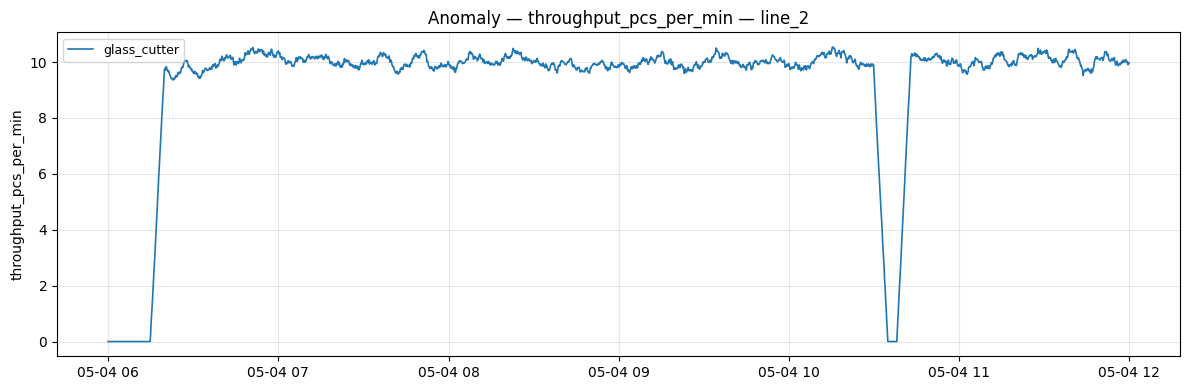

  machine_id  min    max  mean  samples_near_zero  samples_total
glass_cutter  0.0 13.918 9.362                139           2160

Events in window:
                timestamp   machine_id severity     code                                                              message
2026-05-04 10:30:00+00:00 glass_cutter    error DRV_F042             Drive fault: motor over-current sustained. Check axis 2.
2026-05-04 10:32:00+00:00 glass_cutter     info  OP_NOTE Glas blev hængende på transportbåndet. Manuelt frigjort. Kører igen.
2026-05-04 10:38:00+00:00 glass_cutter     info  RESUMED                        Production resumed after manual intervention.

Annotation:
On Monday morning, the glass cutter experienced an anomaly with a throughput of 9.362 pcs per minute. There were 139 samples where the throughput was near zero. The machine had an alarm at 10:30 AM due to a motor over-current fault, and an operator note was recorded at 10:32 AM indicating that the glass was hanging on the transport 

In [9]:
_ = ask(
    'What happened on the glass cutter Monday morning?',
    measurements, events, client,
)

## Live ask — your turn

Use the cell below to type a question the room suggests. Tested questions
that round-trip cleanly through a 3 B local model:

- *Compare motor current across line_3 yesterday.*
- *How did line_1 perform yesterday?*
- *Were there any planned maintenance windows yesterday?*

The pipeline will tell you which signal it picked and what time window it
translated your words into. If the answer looks wrong — say, the model picks
the wrong machine because it misread a proper noun — the schema card is
where you'd nudge it, not the code.

And if a question lands outside the available data window, the annotation
refuses rather than inventing numbers. That refusal is on purpose.

Q: Compare motor current across line_3 yesterday.
  client: ollama   intent: compare   signal: motor_current_a


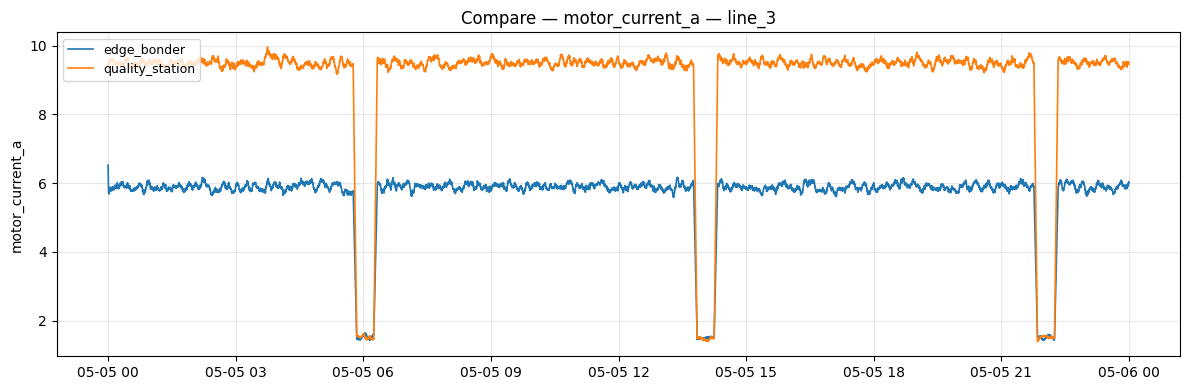

     machine_id  mean
    edge_bonder 5.629
quality_station 9.016

Annotation:
Yesterday, the mean motor current for machine "edge_bonder" was 5.629 amperes, while for machine "quality_station" it was 9.016 amperes. There were no alarms or MES messages or operator notes in the window.


In [10]:
_ = ask(
    'Compare motor current across line_3 yesterday.',
    measurements, events, client,
)

## Take-home

1. **The LLM is a communication layer, not an execution layer.** Plans go in
   as JSON; numbers come out of pandas. The model never touches a database
   directly and never invents a metric.
2. **The schema card is the governance surface.** Your platform team owns
   it. New signals, new machines, new safe time windows all happen there.
3. **Small models are good enough for this job.** This whole demo runs on
   a laptop with a 3 B-parameter local model. No data leaves the building.
4. **Graceful degradation is the design.** If the model is unavailable or
   returns garbage, the demo still produces a chart. Build for the day the
   GPU is busy.

Frame in the room: *this is one of your Kafka topics, plus 200 lines of
Python, plus a 3-billion-parameter model that already lives on your laptop.*
The platform substrate — the container platform and the Kafka backbone —
is already in place. The thin AI layer is the additive step.